**Task 4: Predicting Insurance Claim Amounts**

**Introduction and Problem Statement**

The objective of this task is to predict the medical insurance charges based on personal attributes such as age, BMI, smoking status, and region. This is a regression problem where the target variable is charges.

**Dataset Understanding and Description**

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('insurance.csv')

# Display dataset structure
print("Shape:", df.shape)
print("Columns:", df.columns)
print(df.head())

Shape: (1338, 7)
Columns: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


**Data Cleaning and Preparation**

In [3]:
# Check missing values
print(df.isnull().sum())

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


**Exploratory Data Analysis** (EDA)

**Histogram of Charges**

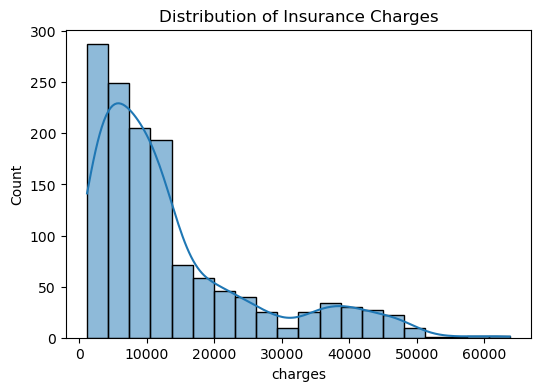

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['charges'], bins=20, kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

**Scatter Plot** (BMI vs Charges)

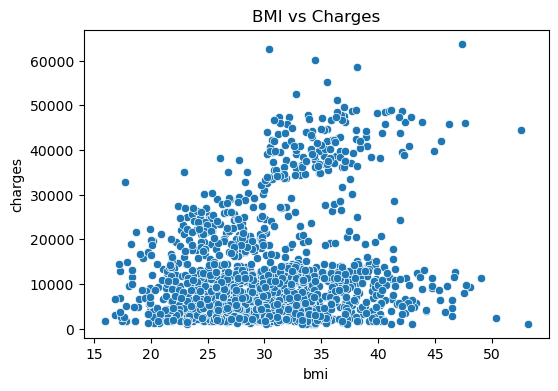

In [6]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

**Box Plot** (Smoker vs Charges)

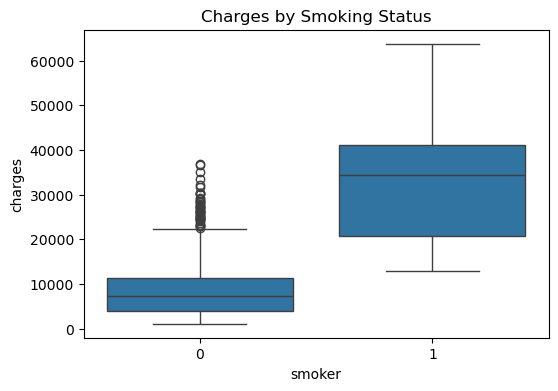

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoking Status")
plt.show()

**Model Training and Testing**

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

**Evaluation Metrics** (MAE & RMSE)

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

MAE: 3762.559965126956
RMSE: 5494.031235864512


**Conclusion**

The Linear Regression model is used to predict insurance charges based on personal data. The evaluation metrics MAE and RMSE indicate how close the predicted values are to actual charges. Factors such as BMI and smoking status significantly influence insurance costs.